In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
# 0. 라이브러리 임포트 & 경로 설정

import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import subprocess
import matplotlib as mpl
import numpy as np
import matplotlib.patches as patches
!pip3 install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
import shutil
import unicodedata
!pip3 install iterative-stratification -q
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


In [45]:
import unicodedata

# ── 디바이스 ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 한글 폰트 ─────────────────────────────────────────────
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ─────────────────────────────────────────────
BASE_DIR            = unicodedata.normalize('NFC', "/content/drive/MyDrive/data/초급_프로젝트/dataset/")

TRAIN_JSON_PATH     = os.path.join(BASE_DIR, "merged_annotations_train_final.json")
TEST_JSON_PATH      = os.path.join(BASE_DIR, "merged_annotations_test_final.json")
TRAIN_IMG_DIR       = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v3.json")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_v3")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v3")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_v3.csv")

for d in [YOLO_DATASET_DIR, YOLO_RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 경로 검증 ─────────────────────────────────────────────
for name, path in [
    ("TRAIN JSON   ", TRAIN_JSON_PATH),
    ("TEST  JSON   ", TEST_JSON_PATH),
    ("TRAIN IMG DIR", TRAIN_IMG_DIR),
    ("TEST  IMG DIR", TEST_IMG_DIR),
]:
    print(f"  {name} : {'OK' if os.path.exists(path) else '없음'} ({path})")

Device: cuda
  TRAIN JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json)
  TEST  JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json)
  TRAIN IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images)
  TEST  IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images)


In [46]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for entry in os.scandir(directory)
        if entry.is_file() and entry.name.lower().endswith(IMG_EXTENSIONS)
    )

EXPECTED = {"Train": 1489, "Test": 843}

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}  (기대값: {EXPECTED['Train']:,})")
print(f"Test  이미지 수 : {n_test:,}  (기대값: {EXPECTED['Test']:,})")
print(f"합계            : {n_train + n_test:,}")

if n_train != EXPECTED["Train"]:
    print(f"[경고] Train 이미지 수 불일치: {n_train} != {EXPECTED['Train']}")
if n_test != EXPECTED["Test"]:
    print(f"[경고] Test  이미지 수 불일치: {n_test} != {EXPECTED['Test']}")

Train 이미지 수 : 1,489  (기대값: 1,489)
Test  이미지 수 : 843  (기대값: 843)
합계            : 2,332


In [49]:
# 샘플 데이터 구조 확인
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# ── 최상위 키 및 건수 ──────────────────────────────────────
for label, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{label}] 최상위 키: {list(data.keys())}")
    print(f"  images      : {len(data.get('images', [])):,}건")
    print(f"  annotations : {len(data.get('annotations', [])):,}건")
    print(f"  categories  : {len(data.get('categories', [])):,}건")
    print()

# ── 샘플 1건씩 출력 ───────────────────────────────────────
print("=== images[0] ===")
print(train_json['images'][0])

print("\n=== annotations[0] ===")
print(train_json['annotations'][0])

print("\n=== categories (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

# ── category_id 범위 및 연속성 확인 ──────────────────────
cat_ids = sorted(c['id'] for c in train_json['categories'])
expected_ids = list(range(min(cat_ids), max(cat_ids) + 1))
is_continuous = cat_ids == expected_ids

print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"연속성           : {'연속' if is_continuous else '[경고] 불연속 (재매핑 필요)'}")


[Train] 최상위 키: ['images', 'annotations', 'categories']
  images      : 1,489건
  annotations : 4,526건
  categories  : 73건

[Test] 최상위 키: ['images', 'annotations', 'categories']
  images      : 843건
  annotations : 1,129건
  categories  : 73건

=== images[0] ===
{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date

클래스 수 : 73  |  전체 어노테이션 : 4,526
평균 : 62.0  |  중앙값 : 35.0  |  최대/최소 비율 : 73.4x

최다 : 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 : 브린텔릭스정 20mg (7개)

상위 5개:
              name  count
기넥신에프정(은행엽엑스)(수출용)    514
       일양하이트린정 2mg    240
        보령부스파정 5mg    180
       뮤테란캡슐 100mg    172
       가바토파정 100mg    143

하위 5개:
        name  count
 졸로푸트정 100mg     11
  쿠에타핀정 25mg     10
자이프렉사정 2.5mg      9
  렉사프로정 15mg      9
 브린텔릭스정 20mg      7


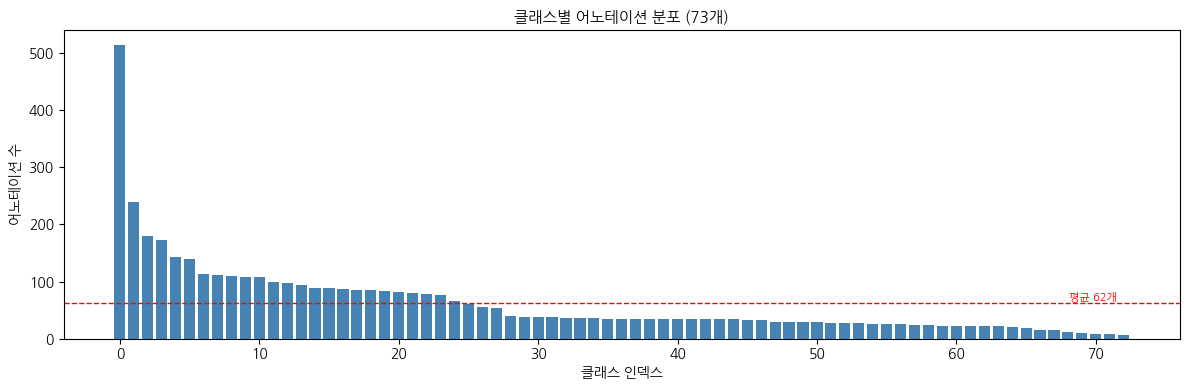

In [6]:
# 클래스 분포 확인
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"클래스 수 : {len(df_class)}  |  전체 어노테이션 : {df_class['count'].sum():,}")
print(f"평균 : {df_class['count'].mean():.1f}  |  중앙값 : {df_class['count'].median():.1f}  |  최대/최소 비율 : {df_class['count'].max() / df_class['count'].min():.1f}x")
print(f"\n최다 : {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 : {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")

print("\n상위 5개:")
print(df_class.head(5)[['name', 'count']].to_string(index=False))
print("\n하위 5개:")
print(df_class.tail(5)[['name', 'count']].to_string(index=False))

# 전체 분포 시각화
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='none')
mean_val = df_class['count'].mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
ax.text(len(df_class) * 0.98, mean_val + 5, f"평균 {mean_val:.0f}개", color='red', fontsize=8, ha='right')
ax.set_title('클래스별 어노테이션 분포 (73개)', fontsize=11)
ax.set_xlabel('클래스 인덱스')
ax.set_ylabel('어노테이션 수')
plt.tight_layout()
plt.show()

[Train] 해상도 분포:
  976 x 1280: 1489장
[Test] 해상도 분포:
  976 x 1280: 843장

annotation 없는 이미지: 0장
평균 알약 수: 3.04개 | 최대: 4개

  1개:   64장 (4.3%)
  2개:  302장 (20.3%)
  3개:  634장 (42.6%)
  4개:  489장 (32.8%)


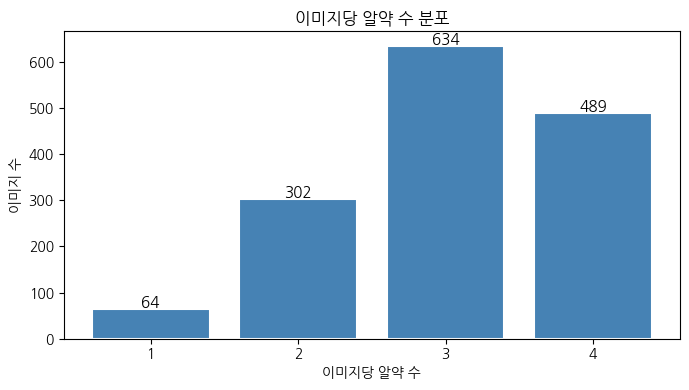

In [7]:
# 해상도 및 알약 수 분포 확인
for label, data in [("Train", train_json), ("Test", test_json)]:
    resolutions = Counter((img['width'], img['height']) for img in data['images'])
    print(f"[{label}] 해상도 분포:")
    for (w, h), cnt in resolutions.most_common():
        print(f"  {w} x {h}: {cnt}장")

ann_per_image = Counter(ann['image_id'] for ann in train_json['annotations'])
no_ann = {img['id'] for img in train_json['images']} - set(ann_per_image.keys())
print(f"\nannotation 없는 이미지: {len(no_ann)}장")

counts = list(ann_per_image.values())
pill_dist = Counter(counts)
print(f"평균 알약 수: {np.mean(counts):.2f}개 | 최대: {np.max(counts)}개\n")
for k in sorted(pill_dist.keys()):
    print(f"  {k}개: {pill_dist[k]:4d}장 ({pill_dist[k]/len(train_json['images'])*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
keys, vals = zip(*sorted(pill_dist.items()))
bars = ax.bar(keys, vals, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('이미지당 알약 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 알약 수 분포')
ax.set_xticks(keys)
plt.tight_layout()
plt.show()

In [8]:
# 비정상 BBox 탐지
img_id2info = {img['id']: img for img in train_json['images']}
invalid_bboxes = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    reasons = []
    if x < 0 or y < 0:           reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:          reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:                reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:                reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")
    if reasons:
        invalid_bboxes.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

print(f"비정상 BBox 수: {len(invalid_bboxes)}개")
for item in invalid_bboxes:
    print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} / bbox={item['bbox']} / 사유={item['reason']}")

비정상 BBox 수: 2개
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)


In [9]:
# ── file_name ↔ 실제 파일 매칭 검증 ──────────────────────
actual_files = {entry.name for entry in os.scandir(TRAIN_IMG_DIR) if entry.is_file()}

missing = []
for img in train_json['images']:
    if img['file_name'] not in actual_files:
        missing.append(img['file_name'])

print(f"JSON 등록 이미지 수  : {len(train_json['images']):,}장")
print(f"실제 파일 수         : {len(actual_files):,}장")
print(f"매칭 실패 (누락 파일): {len(missing)}장")

if missing:
    print("\n누락 파일 목록:")
    for f in missing:
        print(f"  {f}")
else:
    print("모든 파일 정상 매칭")

JSON 등록 이미지 수  : 1,489장
실제 파일 수         : 1,489장
매칭 실패 (누락 파일): 0장
모든 파일 정상 매칭


In [10]:
# 비정상 BBox 제거
invalid_ann_ids = {item['ann_id'] for item in invalid_bboxes}
clean_annotations = [ann for ann in train_json['annotations'] if ann['id'] not in invalid_ann_ids]

print(f"제거 전 : {len(train_json['annotations']):,}개")
print(f"제거 수 : {len(invalid_ann_ids)}개")
print(f"제거 후 : {len(clean_annotations):,}개")

제거 전 : 4,526개
제거 수 : 2개
제거 후 : 4,524개


In [11]:
# category_id 재매핑 (원본 id → 0~72 연속 정수)
sorted_cats = sorted(train_json['categories'], key=lambda c: c['id'])

old_id2new  = {cat['id']: new_id for new_id, cat in enumerate(sorted_cats)}
new_id2old  = {new_id: cat['id'] for new_id, cat in enumerate(sorted_cats)}
new_id2name = {new_id: cat['name'].strip() for new_id, cat in enumerate(sorted_cats)}

remapped_annotations = []
for ann in clean_annotations:
    new_ann = ann.copy()
    new_ann['category_id'] = old_id2new[ann['category_id']]
    remapped_annotations.append(new_ann)

remapped_categories = [
    {'id': new_id, 'name': new_id2name[new_id], 'supercategory': 'pill'}
    for new_id in range(len(sorted_cats))
]

new_cat_ids = sorted(set(ann['category_id'] for ann in remapped_annotations))
print(f"category_id 범위 : {min(new_cat_ids)} ~ {max(new_cat_ids)}")
print(f"고유 클래스 수   : {len(new_cat_ids)}개")
print(f"연속성           : {'연속' if new_cat_ids == list(range(len(new_cat_ids))) else '[경고] 불연속'}")
print(f"annotation 수    : {len(remapped_annotations):,}개")

category_id 범위 : 0 ~ 72
고유 클래스 수   : 73개
연속성           : 연속
annotation 수    : 4,524개


In [12]:
# Train/Val Multi-label Stratified Split
processed_annotations = remapped_annotations

# 이미지별 annotation 그룹화
img2anns = {}
for ann in processed_annotations:
    img2anns.setdefault(ann['image_id'], []).append(ann)

img_ids   = np.array(sorted(img2anns.keys()))
n_classes = len(remapped_categories)

# 이미지별 멀티핫 벡터 생성 (73차원)
y = np.zeros((len(img_ids), n_classes), dtype=int)
for i, img_id in enumerate(img_ids):
    for ann in img2anns[img_id]:
        y[i, ann['category_id']] = 1

# 클래스당 이미지 1장인 경우 강제 train 배정
class_counts     = y.sum(axis=0)
single_classes   = np.where(class_counts == 1)[0]
force_train_mask = np.any(y[:, single_classes] == 1, axis=1) if len(single_classes) > 0 else np.zeros(len(img_ids), dtype=bool)

remaining_idx = np.where(~force_train_mask)[0]
force_idx     = np.where(force_train_mask)[0]

# Multi-label stratified split
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(msss.split(remaining_idx, y[remaining_idx]))

train_ids = img_ids[remaining_idx[train_idx]].tolist() + img_ids[force_idx].tolist()
val_ids   = img_ids[remaining_idx[val_idx]].tolist()

# 검증
train_y = y[[i for i, img_id in enumerate(img_ids) if img_id in set(train_ids)]]
val_y   = y[[i for i, img_id in enumerate(img_ids) if img_id in set(val_ids)]]

print(f"Train : {len(train_ids)}장 | Val : {len(val_ids)}장")
print(f"Train 클래스 수 : {train_y.sum(axis=0).astype(bool).sum()}개")
print(f"Val   클래스 수 : {val_y.sum(axis=0).astype(bool).sum()}개")
print(f"강제 train 배정 : {len(force_idx)}장")

Train : 1182장 | Val : 307장
Train 클래스 수 : 73개
Val   클래스 수 : 73개
강제 train 배정 : 0장


In [13]:
# 전처리 JSON 저장
processed_json = {
    'images'     : train_json['images'],
    'annotations': processed_annotations,
    'categories' : remapped_categories,
    'train_ids'  : list(train_ids),
    'val_ids'    : list(val_ids),
    'mappings'   : {
        'old_id2new' : {str(k): v for k, v in old_id2new.items()},
        'new_id2old' : {str(k): v for k, v in new_id2old.items()},
        'new_id2name': {str(k): v for k, v in new_id2name.items()},
    }
}

with open(PROCESSED_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(processed_json, f, ensure_ascii=False, indent=2)

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    verify = json.load(f)

print(f"images      : {len(verify['images']):,}장")
print(f"annotations : {len(verify['annotations']):,}개")
print(f"categories  : {len(verify['categories'])}개")
print(f"train_ids   : {len(verify['train_ids']):,}장")
print(f"val_ids     : {len(verify['val_ids']):,}장")
cat_ids = [ann['category_id'] for ann in verify['annotations']]
print(f"category_id : {min(cat_ids)} ~ {max(cat_ids)}")

images      : 1,489장
annotations : 4,524개
categories  : 73개
train_ids   : 1,182장
val_ids     : 307장
category_id : 0 ~ 72


In [14]:
# 전처리 최종 검증
train_id_set      = set(train_ids)
val_id_set        = set(val_ids)
train_annotations = [ann for ann in processed_annotations if ann['image_id'] in train_id_set]
val_annotations   = [ann for ann in processed_annotations if ann['image_id'] in val_id_set]

# 1. BBox 좌표 범위 검증
img_id2info = {img['id']: img for img in train_json['images']}
bbox_errors = []
for ann in processed_annotations:
    x, y, w, h = ann['bbox']
    iw = img_id2info[ann['image_id']]['width']
    ih = img_id2info[ann['image_id']]['height']
    reasons = []
    if x < 0 or y < 0:     reasons.append(f"음수 좌표 (x={x:.1f}, y={y:.1f})")
    if w <= 0 or h <= 0:    reasons.append(f"비정상 크기 (w={w:.1f}, h={h:.1f})")
    if x + w > iw:          reasons.append(f"x 범위 초과 ({x+w:.1f} > {iw})")
    if y + h > ih:          reasons.append(f"y 범위 초과 ({y+h:.1f} > {ih})")
    if reasons:
        bbox_errors.append({'ann_id': ann['id'], 'reason': ' / '.join(reasons)})

print(f"비정상 BBox : {len(bbox_errors)}개" + (f"\n  {bbox_errors}" if bbox_errors else " (정상)"))

# 2. Train/Val 클래스 분포 비율 검증
total_cat_counts = Counter(ann['category_id'] for ann in processed_annotations)
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"\n{'new_id':<8} {'클래스명':<30} {'전체':>6} {'Train':>6} {'Val':>5} {'Val비율':>8}")
print("-" * 70)
ratio_errors = []
for cat_id in range(len(remapped_categories)):
    total     = total_cat_counts.get(cat_id, 0)
    train     = train_cat_counts.get(cat_id, 0)
    val       = val_cat_counts.get(cat_id, 0)
    val_ratio = val / total if total > 0 else 0
    flag      = " [경고]" if abs(val_ratio - 0.2) > 0.15 and total >= 5 else ""
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<30} {total:>6} {train:>6} {val:>5} {val_ratio:>7.1%}{flag}")
    if flag:
        ratio_errors.append(cat_id)

print(f"\n비율 이상 클래스 : {len(ratio_errors)}개")
print(f"Train 클래스 수  : {len(train_cat_counts)}개")
print(f"Val   클래스 수  : {len(val_cat_counts)}개")

비정상 BBox : 0개 (정상)

new_id   클래스명                               전체  Train   Val    Val비율
----------------------------------------------------------------------
  0      보령부스파정 5mg                        180    144    36   20.0%
  1      뮤테란캡슐 100mg                       172    140    32   18.6%
  2      일양하이트린정 2mg                       240    192    48   20.0%
  3      기넥신에프정(은행엽엑스)(수출용)                514    411   103   20.0%
  4      무코스타정(레바미피드)(비매품)                  98     78    20   20.4%
  5      알드린정                               54     43    11   20.4%
  6      뉴로메드정(옥시라세탐)                       27     22     5   18.5%
  7      타이레놀정500mg                         33     26     7   21.2%
  8      에어탈정(아세클로페낙)                       29     23     6   20.7%
  9      삼남건조수산화알루미늄겔정                      56     44    12   21.4%
  10     타이레놀이알서방정(아세트아미노펜)(수출용)            35     28     7   20.0%
  11     삐콤씨에프정 618.6mg/병                   34     27     7   20.6%
  12     조인스정 200mg     

In [16]:
# =====================================================================
# 1. 알약 맞춤형 증강(Augmentation) 전략 세팅 (T. alias 사용)
# =====================================================================
# 훈련용(Train): 알약을 여러 각도와 조명에서 본 것처럼 변형 (데이터 뻥튀기 효과)
train_transform = T.Compose([
    T.Resize((224, 224)), # 패딩된 정사각형을 모델 규격에 맞게 축소
    T.RandomRotation(45), # 알약이 놓인 각도는 제각각이므로 최대 45도 회전!
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 조명 변화에 강해지도록 색상 흔들기
    # ⚠️ 주의: 알약의 앞/뒷면 글자(각인)가 뒤집히면 모델이 혼란스러워하므로 RandomHorizontalFlip은 제외합니다.
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet 표준 정규화
])

# 검증용(Val): 꼼수 없이 있는 그대로 정직하게 평가
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =====================================================================
# 2. 커스텀 데이터셋 클래스 (The Cropper & Padder)
# =====================================================================
class PillClassificationDataset(Dataset):
    def __init__(self, json_data, img_dir, target_ids, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # Train 또는 Val에 해당하는 image_id만 필터링해서 어노테이션 저장
        self.target_ids = set(target_ids)
        self.annotations = [ann for ann in json_data['annotations'] if ann['image_id'] in self.target_ids]

        # 이미지 ID로 파일명을 바로 찾기 위한 해시맵 (속도 최적화)
        self.img_info = {img['id']: img['file_name'] for img in json_data['images']}

    def __len__(self):
        # 전체 이미지 장수가 아닌, 잘라낼 '알약의 총 개수'를 반환
        return len(self.annotations)

    def make_square(self, img):
        """
        [필살기] 직사각형 알약을 억지로 찌그러뜨리지 않고,
        긴 쪽에 맞춰 까만색 캔버스를 만든 뒤 정중앙에 알약을 붙여 정사각형으로 만듭니다.
        """
        max_size = max(img.size) # 가로, 세로 중 더 긴 길이 추출
        # 까만색(0, 0, 0) 정사각형 배경 생성
        new_img = Image.new("RGB", (max_size, max_size), (0, 0, 0))
        # 중앙에 원본 알약 이미지 붙여넣기
        new_img.paste(img, ((max_size - img.size[0]) // 2, (max_size - img.size[1]) // 2))
        return new_img

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_id = ann['image_id']
        category_id = ann['category_id'] # 0~72의 연속된 정답 라벨

        # 1. 원본 이미지 불러오기
        img_path = os.path.join(self.img_dir, self.img_info[img_id])
        image = Image.open(img_path).convert("RGB")

        # 2. BBox 좌표(x, y, w, h)로 알약 부위만 정밀하게 싹둑! (Crop)
        x, y, w, h = ann['bbox']
        cropped_image = image.crop((x, y, x + w, y + h))

        # 3. 찌그러짐 방지용 정사각형 패딩
        squared_image = self.make_square(cropped_image)

        # 4. 증강(Transform) 적용
        if self.transform:
            squared_image = self.transform(squared_image)

        # 이미지 텐서와 정답(라벨) 반환
        return squared_image, torch.tensor(category_id, dtype=torch.long)

In [18]:
# =====================================================================
# 1. 훈련 데이터(Train) 기준 클래스별 빈도수 계산
# =====================================================================
# 이전에 만든 remapped_annotations (0~72로 연속된 라벨) 중 Train 데이터만 사용
train_annotations = [ann for ann in remapped_annotations if ann['image_id'] in set(train_ids)]

# 클래스(0~72)별로 알약이 몇 개씩 있는지 카운트
class_counts = Counter(ann['category_id'] for ann in train_annotations)

# 0번부터 72번까지 순서대로 개수를 리스트로 정리
num_classes = 73
counts_per_class = [class_counts.get(i, 0) for i in range(num_classes)]

# =====================================================================
# 2. 클래스 가중치(Class Weights) 계산 (Inverse Frequency 방식)
# =====================================================================
# 공식: 전체 데이터 수 / (클래스 수 * 해당 클래스 데이터 수)
# 데이터가 적을수록(분모가 작을수록) 가중치(결과값)는 기하급수적으로 커집니다.
total_samples = sum(counts_per_class)

class_weights = []
for count in counts_per_class:
    if count == 0:
        weight = 0.0 # 혹시 데이터가 0개인 클래스가 있다면 0으로 처리 (에러 방지)
    else:
        weight = total_samples / (num_classes * count)
    class_weights.append(weight)

# 파이토치가 읽을 수 있도록 Tensor 형태로 변환 (GPU를 쓴다면 .to(DEVICE) 필수!)
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

# 가중치 확인 (가장 많은 약과 가장 적은 약의 가중치 비교)
print(f"총 학습 데이터 수: {total_samples}개")
print(f"최저 가중치 (흔한 약): {min(class_weights):.4f}")
print(f"최고 가중치 (희귀한 약): {max(class_weights):.4f}")

# =====================================================================
# 3. 손실 함수(Loss Function)에 가중치 장착하기
# =====================================================================
# 분류 모델의 표준 손실 함수인 CrossEntropyLoss에 계산한 가중치를 넣어줍니다.
# 이제 모델이 희귀한 약을 틀리면, 이 가중치가 곱해져서 엄청난 페널티를 받게 됩니다!
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# (참고) 이후 학습 루프에서 사용할 때:
# outputs = model(images)
# loss = criterion(outputs, labels) # 알아서 가중치가 적용된 Loss가 계산됨!

총 학습 데이터 수: 3607개
최저 가중치 (흔한 약): 0.1202
최고 가중치 (희귀한 약): 8.2352


In [23]:
import shutil
import time
import os
from torch.utils.data import DataLoader

# 코랩 '내부'의 초고속 SSD 공간 (코랩 안의 임시 작업장)
FAST_COLAB_DIR = '/content/fast_train_images'

if not os.path.exists(FAST_COLAB_DIR):
    print("📥 구글 드라이브에서 코랩 내부 SSD로 이미지를 1회 복사합니다... (약 1~2분 소요)")
    start_copy = time.time()
    # 드라이브의 이미지를 코랩의 초고속 방으로 복사!
    shutil.copytree(TRAIN_IMG_DIR, FAST_COLAB_DIR)
    print(f"✅ 복사 완료! (소요 시간: {time.time() - start_copy:.1f}초)")
else:
    print("✅ 이미 코랩 내부 SSD에 데이터가 있습니다.")

# ------------------------------------------------------------------
# 데이터셋이 바라보는 사진첩 경로만 드라이브에서 '초고속 방'으로 바꿔줍니다.
# ------------------------------------------------------------------
train_dataset = PillClassificationDataset(processed_json, FAST_COLAB_DIR, train_ids, transform=train_transform)
val_dataset = PillClassificationDataset(processed_json, FAST_COLAB_DIR, val_ids, transform=val_transform)

# 데이터 로더 재가동
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("🚀 코랩 내부 초고속 데이터 로더 장착 완료!")

📥 구글 드라이브에서 코랩 내부 SSD로 이미지를 1회 복사합니다... (약 1~2분 소요)
✅ 복사 완료! (소요 시간: 34.9초)
🚀 코랩 내부 초고속 데이터 로더 장착 완료!


### DataLoader 및 분류 파이프라인 구성
 - 모델 : ResNet-50 (Image Classification)

딥러닝 이미지 분류의 베이스라인(표준) 모델입니다. 객체 탐지 모델과 달리, 어노테이션(BBox)을 활용해 알약 부위만 정밀하게 잘라내어(Crop) 모델에 입력하므로 배경 노이즈를 완벽하게 차단하고 다중 클래스(73종) 분류 정밀도를 극한으로 끌어올릴 수 있습니다.

    - 장점: 배경 노이즈 차단으로 분류 정확도 극대화, 안정적인 학습 수렴, 클래스 가중치(Class Weight)를 통한 데이터 불균형 정밀 제어 가능

    - 단점: 원본 이미지에서 객체만 잘라내고 비율을 맞추는 커스텀 데이터 파이프라인 구축 필수

    - 권장 batch_size: 32~64

    - 권장 모델 크기: ResNet-50 (성능/연산량의 표준)


    - 사전학습 가중치: IMAGENET1K_V1

    - 아키텍처 개조: 최종 출력층(fc layer)을 1,000개에서 73개 클래스로 변경

#### 데이터
- 이미지 크기: 224 × 224 (알약 찌그러짐을 방지하는 Zero-padding 적용 후 리사이즈)

- 클래스 수: 73

- Train: 3,607개 / Val: 917개 (원본 이미지가 아닌, BBox 기준으로 잘라낸 '알약 단독 이미지' 개수)

- 포맷: PyTorch Tensor (ImageNet 표준 평균/표준편차 정규화)

#### 학습 하이퍼파라미터
- epochs: 30

- batch_size: 32

- optimizer: AdamW (weight_decay=0.0001)

- learning_rate: 0.001

- loss_function: CrossEntropyLoss (73배율 Inverse Frequency 클래스 가중치 장착)

#### 데이터 증강 (Custom Transforms)
- Square Padding (make_square): 활성화 (형태 보존)

- RandomRotation (최대 45도): 활성화

- ColorJitter (밝기/대비/채도 0.2): 활성화

- RandomHorizontalFlip / VerticalFlip: 비활성화 (알약 표면의 각인/텍스트 정보 훼손 방지)


In [24]:
import time
import copy
from sklearn.metrics import f1_score
import torchvision.models as models

# 1. 데이터 로더 세팅
BATCH_SIZE = 32

train_dataset = PillClassificationDataset(processed_json, TRAIN_IMG_DIR, train_ids, transform=train_transform)
val_dataset = PillClassificationDataset(processed_json, TRAIN_IMG_DIR, val_ids, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train 데이터 로더 준비 완료: {len(train_loader)} 배치")
print(f"Val 데이터 로더 준비 완료: {len(val_loader)} 배치")

# ResNet-50 모델 불러오기 및 개조
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 73개 클래스에 맞게 최종 출력층 수정
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 73)

model = model.to(DEVICE)

# 채점 기준(Loss)과 학습 방법(Optimizer) 세팅
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)

# 학습 루프
EPOCHS = 30
best_f1_score = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

save_path = os.path.join(YOLO_RUNS_DIR, "best_resnet50.pt") if 'YOLO_RUNS_DIR' in locals() else "best_resnet50.pt"

print("\nResNet-50 학습을 시작합니다!")
for epoch in range(EPOCHS):
    start_time = time.time()

    # [Train 모드]
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # [Validation 모드]
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / total
    val_acc = correct / total

    val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    epoch_time = time.time() - start_time
    print(f"[Epoch {epoch+1:2d}/{EPOCHS}] Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    # [Best Model 저장]
    if val_f1 > best_f1_score:
        best_f1_score = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_path)
        print(f"  갱신! Best F1-Score: {best_f1_score:.4f} (저장 경로: {save_path})")

print(f"\n학습 완료! 최종 최고 Val Macro F1-Score: {best_f1_score:.4f}")

Train 데이터 로더 준비 완료: 112 배치
Val 데이터 로더 준비 완료: 29 배치

ResNet-50 학습을 시작합니다!
[Epoch  1/30] Time: 203.1s | Train Loss: 3.6448 Acc: 0.1540 | Val Loss: 2.6422 Acc: 0.2694 F1: 0.1345
  갱신! Best F1-Score: 0.1345 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  2/30] Time: 205.6s | Train Loss: 2.3320 Acc: 0.3825 | Val Loss: 1.7762 Acc: 0.5387 F1: 0.3097
  갱신! Best F1-Score: 0.3097 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  3/30] Time: 207.4s | Train Loss: 1.6845 Acc: 0.5220 | Val Loss: 1.4066 Acc: 0.6150 F1: 0.4607
  갱신! Best F1-Score: 0.4607 (저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)
[Epoch  4/30] Time: 207.1s | Train Loss: 1.3906 Acc: 0.5804 | Val Loss: 1.3701 Acc: 0.5562 F1: 0.4502
[Epoch  5/30] Time: 203.4s | Train Loss: 1.3243 Acc: 0.5951 | Val Loss: 3.2256 Acc: 0.3784 F1: 0.3155
[Epoch  6/30] Time: 208.2s | Train Loss: 1.2529 Acc: 0.6250 | Val Loss: 0.8057 Acc: 

KeyboardInterrupt: 

In [25]:
import os
# 경로가 맞는지 확인 (본인의 경로에 맞춰 수정)
RESNET_MODEL_PATH = os.path.join(YOLO_RUNS_DIR, "best_resnet50.pt")

if os.path.exists(RESNET_MODEL_PATH):
    print(f"✅ 베스트 모델 확인 완료! (경로: {RESNET_MODEL_PATH})")
else:
    print("❌ 모델 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

✅ 베스트 모델 확인 완료! (경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_v3/best_resnet50.pt)



- 골든 크로스 (Good): Train Loss와 Val Loss가 나란히 사이좋게 아래로 내려가는 모습.

- 과적합의 서막 (Bad): Train Loss는 계속 내려가는데, Val Loss가 V자 형태로 다시 고개를 쳐드는 지점. 그 V자의 변곡점이 바로 학습을 멈췄어야 하는 최적의 지점입니다.

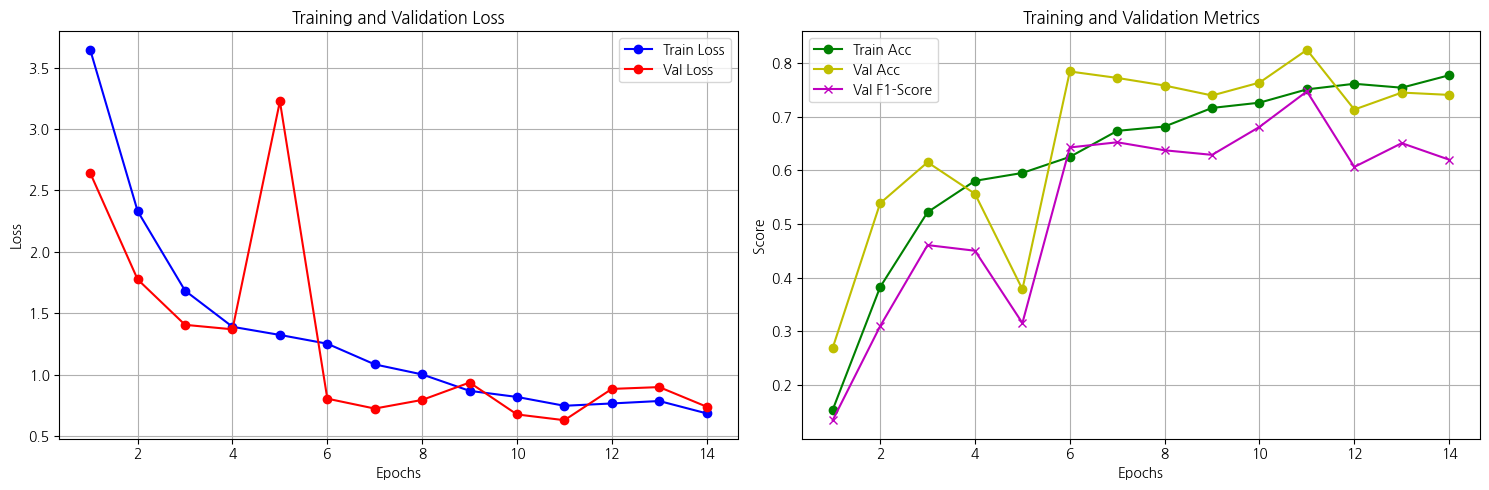

In [28]:
import matplotlib.pyplot as plt

# 1. 주신 로그에서 추출한 데이터 (1~14 Epoch)
train_losses = [3.6448, 2.3320, 1.6845, 1.3906, 1.3243, 1.2529, 1.0846, 1.0029, 0.8693, 0.8196, 0.7477, 0.7666, 0.7865, 0.6858]
val_losses   = [2.6422, 1.7762, 1.4066, 1.3701, 3.2256, 0.8057, 0.7250, 0.7954, 0.9369, 0.6772, 0.6303, 0.8850, 0.8998, 0.7401]
train_accs   = [0.1540, 0.3825, 0.5220, 0.5804, 0.5951, 0.6250, 0.6735, 0.6816, 0.7162, 0.7260, 0.7508, 0.7612, 0.7539, 0.7771]
val_accs     = [0.2694, 0.5387, 0.6150, 0.5562, 0.3784, 0.7841, 0.7721, 0.7579, 0.7394, 0.7634, 0.8244, 0.7132, 0.7448, 0.7405]
val_f1s      = [0.1345, 0.3097, 0.4607, 0.4502, 0.3155, 0.6426, 0.6522, 0.6373, 0.6288, 0.6809, 0.7471, 0.6063, 0.6506, 0.6198]

def plot_learning_curves(train_losses, val_losses, train_accs, val_accs, val_f1s):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(15, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-o', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Metrics 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'g-o', label='Train Acc')
    plt.plot(epochs, val_accs, 'y-o', label='Val Acc')
    plt.plot(epochs, val_f1s, 'm-x', label='Val F1-Score')
    plt.title('Training and Validation Metrics')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 출력
plot_learning_curves(train_losses, val_losses, train_accs, val_accs, val_f1s)

In [70]:
import torch
import pandas as pd
import os, json, unicodedata
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO

# --- [1. 경로 재설정 (세션 복원)] ---
BASE_DIR            = unicodedata.normalize('NFC', "/content/drive/MyDrive/data/초급_프로젝트/dataset/")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_v3")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_v3.json")

# 모델 경로들
RESNET_MODEL_PATH = os.path.join(YOLO_RUNS_DIR, "best_resnet50.pt")
YOLO_MODEL_PATH   = os.path.join(YOLO_RUNS_DIR, "yolov8m_oral_drug_v3", "weights", "best.pt")
FINAL_SUB_PATH    = os.path.join(BASE_DIR, "submission_ResNet_Dew.csv")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- [2. 족보(JSON) 데이터 다시 로드] ---
with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    processed_json = json.load(f)
new_id2old = {int(k): v for k, v in processed_json['mappings']['new_id2old'].items()}

# --- [3. 모델 로드 및 전처리 설정 - 수정본] ---
from torchvision import models
from torch import nn

# 1. YOLO 로드
yolo_model = YOLO(YOLO_MODEL_PATH)

# 2. ResNet-50 로드 (구조를 먼저 만들고 가중치를 입힙니다)
resnet_model = models.resnet50(weights=None)
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 73) # 클래스 수 73개에 맞게 수정

# 가중치 파일 로드
checkpoint = torch.load(RESNET_MODEL_PATH, map_location=DEVICE)

# 불러온 파일이 가중치(dict)인 경우와 모델 전체인 경우를 모두 처리합니다.
if isinstance(checkpoint, dict):
    if 'model_state_dict' in checkpoint:
        resnet_model.load_state_dict(checkpoint['model_state_dict'])
    else:
        resnet_model.load_state_dict(checkpoint)
else:
    resnet_model = checkpoint

resnet_model.to(DEVICE)
resnet_model.eval()

# 전처리 설정은 기존과 동일
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("모델 로드 완료! 이제 추론을 시작합니다.")

test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')])

# --- [4. 추론 루프] ---
# 파일 목록 다시 정의 (NameError 방지)
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')])

print(f"추론 시작: 총 {len(test_files)}장")

with torch.no_grad():
    for f in test_files:
        img_path = os.path.join(TEST_IMG_DIR, f)
        image_id = int(os.path.splitext(f)[0])
        origin_img = Image.open(img_path).convert('RGB')

        # YOLO 위치 탐지
        results = yolo_model.predict(source=img_path, imgsz=1280, conf=0.25, verbose=False)
        boxes = results[0].boxes

        if boxes:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                cropped = origin_img.crop((x1, y1, x2, y2))

                # ResNet-50 정밀 분류
                input_tensor = resnet_transform(cropped).unsqueeze(0).to(DEVICE)
                output = resnet_model(input_tensor)
                _, pred_idx = torch.max(output, 1)

                # ID 매핑 및 보정
                orig_cat = new_id2old[pred_idx.item()] + 1

                rows.append({
                    "image_id": image_id,
                    "category_id": orig_cat,
                    "bbox_x": round(x1, 1),
                    "bbox_y": round(y1, 1),
                    "bbox_w": round(x2 - x1, 1),
                    "bbox_h": round(y2 - y1, 1),
                    "score": float(box.conf[0])
                })

# --- [5. Pandas 후처리 및 저장] ---
# ---------------------------------------------------------
# 기존에 rows.append(...)가 완료된 시점 이후부터 실행
# ---------------------------------------------------------

# 1. 리스트를 데이터프레임으로 변환
df_sub = pd.DataFrame(rows)

# 2. 대회 규정에 맞게 데이터 보정
if not df_sub.empty:
    # (1) image_id를 정수(int)로 변환 (예: '0001' -> 1)
    # 만약 이미 정수라면 이 줄은 건너뛰어도 되지만, 안전하게 한 번 더 처리합니다.
    df_sub['image_id'] = df_sub['image_id'].astype(int)

    # (2) 이미지당 점수가 높은 순으로 정렬 후 상위 4개만 남김
    df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
    df_sub = df_sub.groupby("image_id").head(4)

    # (3) annotation_id를 1부터 순차적으로 새로 부여 (기존 ID 삭제 후 삽입)
    if 'annotation_id' in df_sub.columns:
        df_sub = df_sub.drop(columns=['annotation_id'])
    df_sub.insert(0, 'annotation_id', range(1, len(df_sub) + 1))

# 3. 최종 CSV 저장
output_name = "submission_ResNet_Dew.csv"
df_sub.to_csv(os.path.join(BASE_DIR, output_name), index=False)

print(f"제출 파일 교정 완료: {output_name}")
print(f"최종 객체 수: {len(df_sub)}개")
print(df_sub.head())

모델 로드 완료! 이제 추론을 시작합니다.
추론 시작: 총 843장
제출 파일 교정 완료: submission_ResNet_Dew.csv
최종 객체 수: 3372개
      annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
0                 1         1        21771   598.7   674.9   258.1   479.0   
3235              2         1        21771   598.7   674.9   258.1   479.0   
1                 3         1        24850   172.0   742.2   182.5   292.2   
3236              4         1        24850   172.0   742.2   182.5   292.2   
1557              5         3        21771   571.2   626.4   261.3   489.4   

         score  
0     0.951505  
3235  0.951505  
1     0.837656  
3236  0.837656  
1557  0.958199  


In [71]:
# 1. 이름 사전 구축 (KeyError 방지 및 유연한 검색)
id2name = {}
for item in processed_json.get('categories', []):
    idx = item.get('id')
    # name -> drug_name -> title 순으로 서랍을 뒤져서 이름을 가져옵니다.
    name = item.get('name') or item.get('drug_name') or item.get('title') or f"ID:{idx}"
    id2name[idx] = name

# 2. 결과 시각화 함수
def visualize_final_results(model, yolo_model, test_img_dir, test_files, device, num_samples=3):
    samples = random.sample(test_files, num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(21, 10))
    if num_samples == 1: axes = [axes]

    plt.rc('font', family='NanumBarunGothic') # 한글 폰트 설정

    with torch.no_grad():
        for i, f in enumerate(samples):
            img_path = os.path.join(test_img_dir, f)
            origin_img = Image.open(img_path).convert('RGB')
            results = yolo_model.predict(source=img_path, imgsz=1280, conf=0.25, verbose=False)
            boxes = results[0].boxes

            axes[i].imshow(origin_img)
            axes[i].set_title(f"Test Image: {f}", fontsize=15)

            if boxes:
                for box in boxes:
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    cropped = origin_img.crop((x1, y1, x2, y2))
                    input_tensor = resnet_transform(cropped).unsqueeze(0).to(device)
                    output = model(input_tensor)
                    _, pred_idx = torch.max(output, 1)

                    old_id = new_id2old[pred_idx.item()]
                    drug_name = id2name.get(old_id, f"ID:{old_id}")

                    # 디자인: 민트색 박스 + 검은바탕 노란글씨
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='#00FFCC', facecolor='none')
                    axes[i].add_patch(rect)
                    axes[i].text(x1, y1-15, drug_name, color='yellow', fontsize=12, weight='bold',
                                 bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# 실행!
visualize_final_results(resnet_model, yolo_model, TEST_IMG_DIR, test_files, DEVICE)

Output hidden; open in https://colab.research.google.com to view.

In [64]:
def visualize_predictions(model, yolo_model, test_img_dir, test_files, device, num_samples=3):
    samples = random.sample(test_files, num_samples)

    plt.figure(figsize=(20, 10))

    for i, f in enumerate(samples):
        img_path = os.path.join(test_img_dir, f)
        origin_img = Image.open(img_path).convert('RGB')

        # 1. YOLO 위치 탐지
        results = yolo_model.predict(source=img_path, imgsz=1280, conf=0.25, verbose=False)
        boxes = results[0].boxes

        ax = plt.subplot(1, num_samples, i + 1)
        ax.imshow(origin_img)
        ax.set_title(f"File: {f}")

        if boxes:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()

                # 2. ResNet 분류
                cropped = origin_img.crop((x1, y1, x2, y2))
                input_tensor = resnet_transform(cropped).unsqueeze(0).to(device)

                model.eval()
                with torch.no_grad():
                    output = model(input_tensor)
                    _, pred_idx = torch.max(output, 1)

                current_new_id = pred_idx.item()
                display_name = new_id2name.get(current_new_id, f"ID:{current_new_id}")

                # 박스 그리기
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='#00FFCC', facecolor='none')
                ax.add_patch(rect)

                plt.text(x1, y1-15, f"[{current_new_id}] {display_name}",
                         color='yellow', weight='bold', fontsize=12,
                         bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(resnet_model, yolo_model, TEST_IMG_DIR, test_files, DEVICE, num_samples=3)

Output hidden; open in https://colab.research.google.com to view.

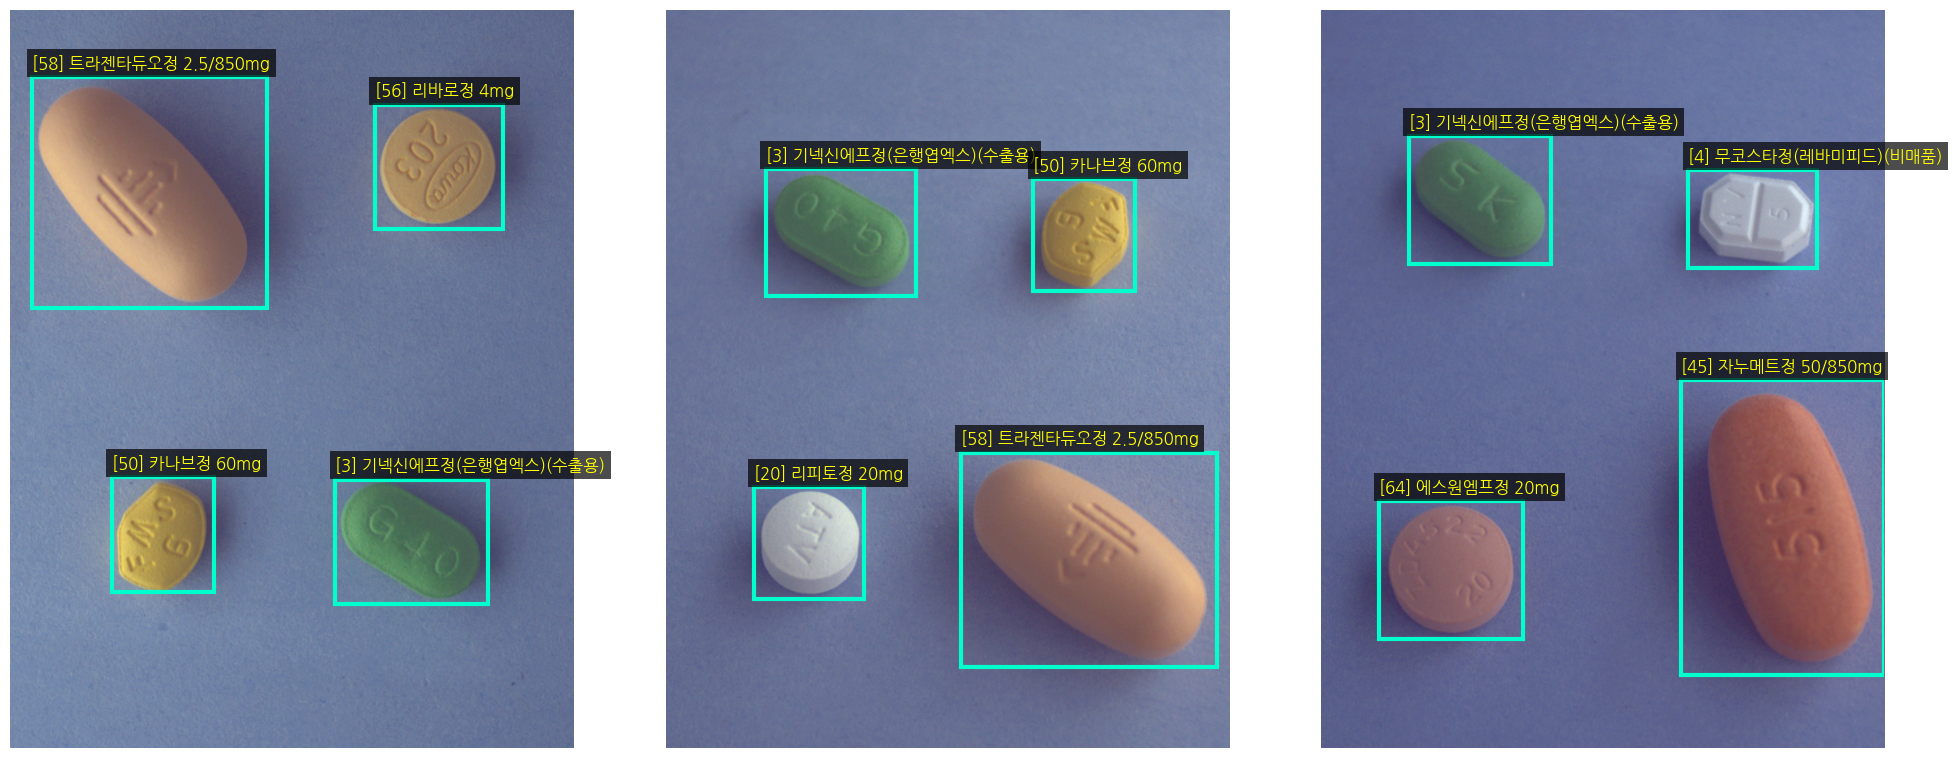

In [69]:
def visualize_predictions(model, yolo_model, test_img_dir, test_files, device, num_samples=3):
    samples = random.sample(test_files, num_samples)

    # 이미 설정하신 한글 폰트 적용
    plt.rc('font', family='NanumGothic')

    plt.figure(figsize=(20, 10))

    for i, f in enumerate(samples):
        img_path = os.path.join(test_img_dir, f)
        origin_img = Image.open(img_path).convert('RGB')

        results = yolo_model.predict(source=img_path, imgsz=1280, conf=0.25, verbose=False)
        boxes = results[0].boxes

        ax = plt.subplot(1, num_samples, i + 1)
        ax.imshow(origin_img)

        if boxes:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()

                cropped = origin_img.crop((x1, y1, x2, y2))
                input_tensor = resnet_transform(cropped).unsqueeze(0).to(device)

                model.eval()
                with torch.no_grad():
                    output = model(input_tensor)
                    _, pred_idx = torch.max(output, 1)

                # [🔥 수정 1] 모델이 예측한 번호(new_id)를 가져옵니다.
                current_new_id = pred_idx.item()

                # [🔥 수정 2] 'new_id2name' 지도에서 진짜 이름을 쏙 뽑습니다.
                # 'df_class' 같은 객체를 쓰지 않고, 딕셔너리에서 직접 글자를 가져오는 게 핵심!
                display_name = new_id2name.get(current_new_id, f"ID:{current_new_id}")

                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='#00FFCC', facecolor='none')
                ax.add_patch(rect)

                # 'display_name'을 넣으면 한글 이름
                plt.text(x1, y1-15, f"[{current_new_id}] {display_name}",
                         color='yellow', weight='bold', fontsize=12,
                         bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(resnet_model, yolo_model, TEST_IMG_DIR, test_files, DEVICE, num_samples=3)